In [31]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from typing import List, Dict, Tuple, Optional

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset, random_split
import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import STL10, OxfordIIITPet

from torchvision.models import resnet18, ResNet18_Weights

try:
    from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
except ImportError:
    try:
        from torchvision.models import deeplabv3_resnet50
        DeepLabV3_ResNet50_Weights = None
    except ImportError:
        deeplabv3_resnet50 = None
        DeepLabV3_ResNet50_Weights = None
        print("Warning: DeepLabV3 not available in this torchvision version")

SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

print(f"PyTorch version: {torch.__version__}")
print(f"Torchvision version: {torchvision.__version__}")
print(f"DeepLabV3 available: {deeplabv3_resnet50 is not None}")

base_dir = Path(".")
artifacts_dir = base_dir / "artifacts"
figures_dir = artifacts_dir / "figures"

artifacts_dir.mkdir(exist_ok=True)
figures_dir.mkdir(exist_ok=True)

print(f"\nArtifacts directory: {artifacts_dir.resolve()}")
print(f"Figures directory: {figures_dir.resolve()}")

Using device: cuda
PyTorch version: 2.7.1+cu118
Torchvision version: 0.22.1+cu118
DeepLabV3 available: True

Artifacts directory: C:\Users\kuzne\ai_engineering\homeworks\HW10-11\artifacts
Figures directory: C:\Users\kuzne\ai_engineering\homeworks\HW10-11\artifacts\figures


In [32]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(96),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(96),
    transforms.CenterCrop(96),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_transform_no_aug = transforms.Compose([
    transforms.Resize(96),
    transforms.CenterCrop(96),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("Loading STL10 dataset...")
train_dataset_full = STL10(root="./data", split="train", download=True, transform=train_transform_aug)
test_dataset = STL10(root="./data", split="test", download=True, transform=val_transform)

print(f"Train dataset size: {len(train_dataset_full)}")
print(f"Test dataset size: {len(test_dataset)}")
print(f"Image shape example: {train_dataset_full[0][0].shape}")
print(f"Number of classes: {len(train_dataset_full.classes)}")
print(f"Classes: {train_dataset_full.classes}")

Loading STL10 dataset...
Train dataset size: 5000
Test dataset size: 8000
Image shape example: torch.Size([3, 96, 96])
Number of classes: 10
Classes: ['airplane', 'bird', 'car', 'cat', 'deer', 'dog', 'horse', 'monkey', 'ship', 'truck']


In [33]:
def split_dataset(dataset, val_ratio=0.2, seed=42):
    generator = torch.Generator().manual_seed(seed)
    train_size = int(len(dataset) * (1 - val_ratio))
    val_size = len(dataset) - train_size
    train_subset, val_subset = random_split(
        dataset, 
        [train_size, val_size],
        generator=generator
    )
    return train_subset, val_subset

train_dataset, val_dataset = split_dataset(train_dataset_full, val_ratio=0.2, seed=SEED)

print(f"\nTrain split: {len(train_dataset)}")
print(f"Val split: {len(val_dataset)}")
print(f"Test split: {len(test_dataset)}")


Train split: 4000
Val split: 1000
Test split: 8000


In [34]:
BATCH_SIZE = 32

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

images, labels = next(iter(train_loader))
print(f"\nBatch images shape: {images.shape}")
print(f"Batch labels shape: {labels.shape}")
print(f"Labels sample: {labels[:10].numpy()}")
print(f"Classes mapping: {dict(enumerate(train_dataset_full.classes))}")


Batch images shape: torch.Size([32, 3, 96, 96])
Batch labels shape: torch.Size([32])
Labels sample: [1 2 8 4 0 8 6 8 5 0]
Classes mapping: {0: 'airplane', 1: 'bird', 2: 'car', 3: 'cat', 4: 'deer', 5: 'dog', 6: 'horse', 7: 'monkey', 8: 'ship', 9: 'truck'}


In [35]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

simple_transform = transforms.Compose([
    transforms.Resize(96),
    transforms.CenterCrop(96),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

simple_transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(96),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_transform_aug = transforms.Compose([
    transforms.RandomResizedCrop(96),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

val_transform = transforms.Compose([
    transforms.Resize(96),
    transforms.CenterCrop(96),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

print("All transforms defined")

All transforms defined


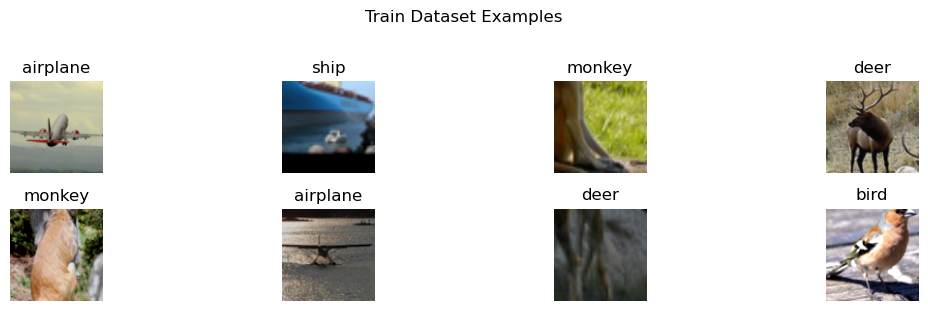

In [36]:
def show_images(images, labels, title="Sample Images", num_images=8):
    fig, axes = plt.subplots(2, num_images//2, figsize=(12, 3))
    axes = axes.flatten()
    
    mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
    std = torch.tensor(IMAGENET_STD).view(3, 1, 1)
    
    for i in range(num_images):
        img = images[i] * std + mean
        img = img.permute(1, 2, 0).clamp(0, 1)
        
        axes[i].imshow(img)
        axes[i].set_title(f"{train_dataset_full.classes[labels[i]]}")
        axes[i].axis('off')
    
    plt.suptitle(title, y=1.02)
    plt.tight_layout()
    plt.show()

images, labels = next(iter(train_loader))
show_images(images, labels, title="Train Dataset Examples", num_images=8)

Saved augmentations preview to artifacts\figures\augmentations_preview.png


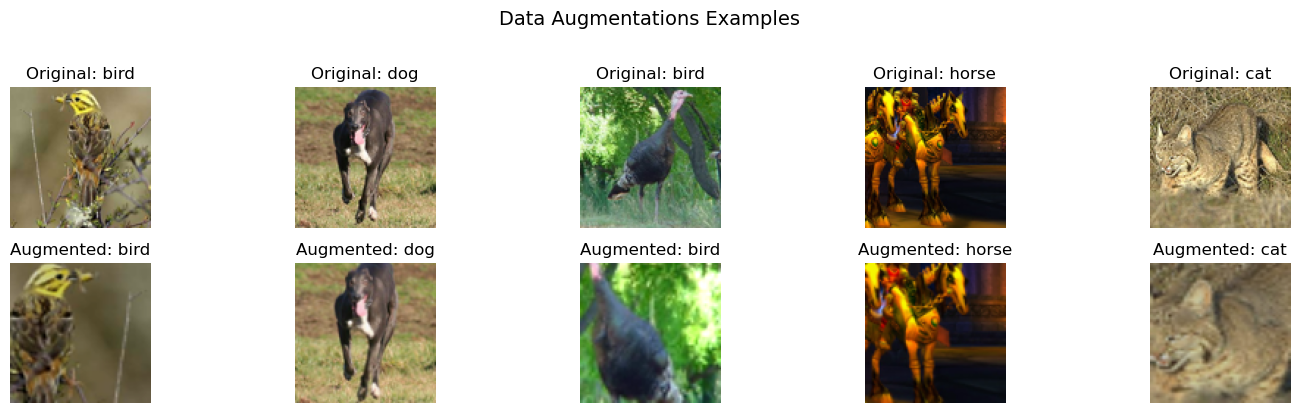

In [37]:
base_dataset = STL10(root="./data", split="train", download=False, transform=simple_transform)
aug_dataset = STL10(root="./data", split="train", download=False, transform=train_transform_aug)

fig, axes = plt.subplots(2, 5, figsize=(15, 4))

mean = torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
std = torch.tensor(IMAGENET_STD).view(3, 1, 1)

for i in range(5):
    img, label = base_dataset[i]
    img = img * std + mean
    img = img.permute(1, 2, 0).clamp(0, 1)
    
    axes[0, i].imshow(img)
    axes[0, i].set_title(f"Original: {base_dataset.classes[label]}")
    axes[0, i].axis('off')

for i in range(5):
    img, label = aug_dataset[i]
    img = img * std + mean
    img = img.permute(1, 2, 0).clamp(0, 1)
    
    axes[1, i].imshow(img)
    axes[1, i].set_title(f"Augmented: {aug_dataset.classes[label]}")
    axes[1, i].axis('off')

plt.suptitle("Data Augmentations Examples", y=1.02, fontsize=14)
plt.tight_layout()

plt.savefig(figures_dir / "augmentations_preview.png", dpi=150, bbox_inches='tight')
print(f"Saved augmentations preview to {figures_dir / 'augmentations_preview.png'}")
plt.show()

In [38]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes=10):
        super(SimpleCNN, self).__init__()
        self.features = nn.Sequential(
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
            
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(256 * 6 * 6, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, num_classes)
        )
    
    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

print("SimpleCNN defined")
print(f"Input shape: (3, 96, 96)")
print(f"Output shape: (10,) for 10 classes")

SimpleCNN defined
Input shape: (3, 96, 96)
Output shape: (10,) for 10 classes


In [39]:
def train_one_epoch(model, loader, criterion, optimizer, device, epoch):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for batch_idx, (inputs, targets) in enumerate(loader):
        inputs, targets = inputs.to(device), targets.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    
    epoch_loss = running_loss / len(loader)
    epoch_acc = 100. * correct / total
    
    return epoch_loss, epoch_acc

print("Training and evaluation functions defined")

Training and evaluation functions defined


In [40]:
train_loader_no_aug = DataLoader(
    Subset(STL10(root="./data", split="train", download=False, transform=simple_transform), 
           range(4000)),
    batch_size=32, shuffle=True, num_workers=2
)

train_loader_aug = DataLoader(
    Subset(STL10(root="./data", split="train", download=False, transform=train_transform_aug), 
           range(4000)),
    batch_size=32, shuffle=True, num_workers=2
)

val_loader_simple = DataLoader(
    Subset(STL10(root="./data", split="train", download=False, transform=val_transform), 
           range(4000, 5000)),
    batch_size=32, shuffle=False, num_workers=2
)

print("DataLoaders for simple CNN ready")
print(f"  - Train (no aug): {len(train_loader_no_aug)} batches")
print(f"  - Train (aug): {len(train_loader_aug)} batches")
print(f"  - Val: {len(val_loader_simple)} batches")

DataLoaders for simple CNN ready
  - Train (no aug): 125 batches
  - Train (aug): 125 batches
  - Val: 32 batches


In [41]:
import time
from collections import defaultdict

results = []

NUM_EPOCHS = 10
LEARNING_RATE = 0.001
NUM_CLASSES = 10

def run_experiment(exp_id, model, train_loader, val_loader, model_name, notes=""):
    print(f"\n{'='*50}")
    print(f"Starting Experiment: {exp_id} ({model_name})")
    print(f"{'='*50}")
    
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
    
    history = {
        'train_loss': [], 'train_acc': [],
        'val_loss': [], 'val_acc': []
    }
    
    best_val_acc = 0.0
    best_model_state = None
    
    for epoch in range(NUM_EPOCHS):
        start_time = time.time()
        
        train_loss, train_acc = train_one_epoch(model, train_loader, criterion, optimizer, device, epoch)
        val_loss, val_acc = evaluate(model, val_loader, criterion, device)
        scheduler.step()
        
        history['train_loss'].append(train_loss)
        history['train_acc'].append(train_acc)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)
        
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_model_state = model.state_dict().copy()
        
        epoch_time = time.time() - start_time
        print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
              f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}% | "
              f"Val Loss: {val_loss:.4f} | Val Acc: {val_acc:.2f}% | "
              f"Time: {epoch_time:.1f}s")
    
    exp_result = {
        'experiment_id': exp_id,
        'task': 'classification',
        'dataset': 'STL10',
        'seed': SEED,
        'model_summary': model_name,
        'optimizer': 'Adam',
        'lr': LEARNING_RATE,
        'epochs_trained': NUM_EPOCHS,
        'best_val_accuracy': best_val_acc,
        'test_accuracy': None,
        'precision': None,
        'recall': None,
        'mean_iou': None,
        'notes': notes
    }
    results.append(exp_result)
    
    print(f"\nExperiment {exp_id} completed! Best Val Accuracy: {best_val_acc:.2f}%")
    
    return model, best_model_state, history, exp_result

In [42]:
torch.manual_seed(SEED)
model_c1 = SimpleCNN(num_classes=NUM_CLASSES)
model_c1, state_c1, history_c1, result_c1 = run_experiment(
    exp_id='C1',
    model=model_c1,
    train_loader=train_loader_no_aug,
    val_loader=val_loader_simple,
    model_name='SimpleCNN',
    notes='No augmentations'
)


Starting Experiment: C1 (SimpleCNN)
Epoch 1/10 | Train Loss: 2.3629 | Train Acc: 26.85% | Val Loss: 1.6226 | Val Acc: 35.60% | Time: 23.8s
Epoch 2/10 | Train Loss: 1.6617 | Train Acc: 34.40% | Val Loss: 1.5696 | Val Acc: 42.60% | Time: 23.5s
Epoch 3/10 | Train Loss: 1.5691 | Train Acc: 38.38% | Val Loss: 1.5435 | Val Acc: 40.60% | Time: 23.9s
Epoch 4/10 | Train Loss: 1.4905 | Train Acc: 41.80% | Val Loss: 1.5767 | Val Acc: 43.80% | Time: 23.2s
Epoch 5/10 | Train Loss: 1.4218 | Train Acc: 44.65% | Val Loss: 1.3114 | Val Acc: 50.20% | Time: 24.1s
Epoch 6/10 | Train Loss: 1.2812 | Train Acc: 50.17% | Val Loss: 1.2234 | Val Acc: 54.70% | Time: 24.5s
Epoch 7/10 | Train Loss: 1.2278 | Train Acc: 52.70% | Val Loss: 1.1892 | Val Acc: 56.10% | Time: 24.4s
Epoch 8/10 | Train Loss: 1.1904 | Train Acc: 55.50% | Val Loss: 1.1611 | Val Acc: 57.70% | Time: 24.3s
Epoch 9/10 | Train Loss: 1.1704 | Train Acc: 55.25% | Val Loss: 1.1308 | Val Acc: 58.60% | Time: 25.2s
Epoch 10/10 | Train Loss: 1.1393 | T

In [43]:
torch.manual_seed(SEED)
model_c2 = SimpleCNN(num_classes=NUM_CLASSES)
model_c2, state_c2, history_c2, result_c2 = run_experiment(
    exp_id='C2',
    model=model_c2,
    train_loader=train_loader_aug,
    val_loader=val_loader_simple,
    model_name='SimpleCNN',
    notes='With augmentations'
)


Starting Experiment: C2 (SimpleCNN)
Epoch 1/10 | Train Loss: 2.5524 | Train Acc: 17.38% | Val Loss: 1.9109 | Val Acc: 27.40% | Time: 25.2s
Epoch 2/10 | Train Loss: 1.9710 | Train Acc: 23.05% | Val Loss: 1.6611 | Val Acc: 30.50% | Time: 25.1s
Epoch 3/10 | Train Loss: 1.8987 | Train Acc: 24.40% | Val Loss: 1.6609 | Val Acc: 31.20% | Time: 26.0s
Epoch 4/10 | Train Loss: 1.9075 | Train Acc: 25.52% | Val Loss: 1.6948 | Val Acc: 29.60% | Time: 25.7s
Epoch 5/10 | Train Loss: 1.8801 | Train Acc: 26.32% | Val Loss: 1.6990 | Val Acc: 28.00% | Time: 25.2s
Epoch 6/10 | Train Loss: 1.8122 | Train Acc: 27.70% | Val Loss: 1.5841 | Val Acc: 36.80% | Time: 29.9s
Epoch 7/10 | Train Loss: 1.7898 | Train Acc: 28.40% | Val Loss: 1.5762 | Val Acc: 35.60% | Time: 27.7s
Epoch 8/10 | Train Loss: 1.7666 | Train Acc: 29.57% | Val Loss: 1.5527 | Val Acc: 37.60% | Time: 27.7s
Epoch 9/10 | Train Loss: 1.7828 | Train Acc: 29.93% | Val Loss: 1.5553 | Val Acc: 35.90% | Time: 27.8s
Epoch 10/10 | Train Loss: 1.7692 | T

In [44]:
print("\nSTARTING C3 EXPERIMENT: ResNet18 Head-Only\n", flush=True)

torch.manual_seed(SEED)

model_c3 = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

num_features = model_c3.fc.in_features
model_c3.fc = nn.Linear(num_features, NUM_CLASSES)

for param in model_c3.parameters():
    param.requires_grad = False
for param in model_c3.fc.parameters():
    param.requires_grad = True

train_loader_resnet = DataLoader(
    Subset(STL10(root="./data", split="train", download=False, transform=val_transform), 
           range(4000)),
    batch_size=32, shuffle=True, num_workers=2
)

val_loader_resnet = DataLoader(
    Subset(STL10(root="./data", split="train", download=False, transform=val_transform), 
           range(4000, 5000)),
    batch_size=32, shuffle=False, num_workers=2
)

model_c3, state_c3, history_c3, result_c3 = run_experiment(
    exp_id='C3',
    model=model_c3,
    train_loader=train_loader_resnet,
    val_loader=val_loader_resnet,
    model_name='ResNet18-HeadOnly',
    notes='Frozen backbone, train FC only'
)

print(f"\n C3 Completed!", flush=True)


STARTING C3 EXPERIMENT: ResNet18 Head-Only


Starting Experiment: C3 (ResNet18-HeadOnly)
Epoch 1/10 | Train Loss: 1.2377 | Train Acc: 60.10% | Val Loss: 0.8472 | Val Acc: 73.70% | Time: 24.4s
Epoch 2/10 | Train Loss: 0.7245 | Train Acc: 77.38% | Val Loss: 0.7629 | Val Acc: 75.10% | Time: 23.8s
Epoch 3/10 | Train Loss: 0.6261 | Train Acc: 78.80% | Val Loss: 0.7203 | Val Acc: 75.70% | Time: 23.6s
Epoch 4/10 | Train Loss: 0.5756 | Train Acc: 81.45% | Val Loss: 0.6974 | Val Acc: 77.30% | Time: 23.6s
Epoch 5/10 | Train Loss: 0.5290 | Train Acc: 82.90% | Val Loss: 0.6672 | Val Acc: 78.20% | Time: 24.8s
Epoch 6/10 | Train Loss: 0.4981 | Train Acc: 83.92% | Val Loss: 0.6774 | Val Acc: 77.70% | Time: 23.5s
Epoch 7/10 | Train Loss: 0.4804 | Train Acc: 84.22% | Val Loss: 0.6791 | Val Acc: 77.30% | Time: 24.6s
Epoch 8/10 | Train Loss: 0.4791 | Train Acc: 84.03% | Val Loss: 0.6853 | Val Acc: 77.50% | Time: 24.0s
Epoch 9/10 | Train Loss: 0.4632 | Train Acc: 84.58% | Val Loss: 0.6828 | Val Acc: 76.7

In [45]:
from tqdm import tqdm


In [46]:
def train_one_epoch(model, loader, criterion, optimizer, device, epoch, total_epochs):
    model.train()
    running_loss, correct, total = 0.0, 0, 0
    pbar = tqdm(loader, desc=f"Ep {epoch+1}/{total_epochs} [Train]", leave=False)
    for inputs, targets in pbar:
        inputs, targets = inputs.to(device), targets.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, targets)
        loss.backward()
        optimizer.step()
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += targets.size(0)
        correct += predicted.eq(targets).sum().item()
        pbar.set_postfix({'loss': f'{loss.item():.3f}'})
    return running_loss/len(loader), 100.*correct/total

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return running_loss/len(loader), 100.*correct/total

print("Functions updated", flush=True)

Functions updated


In [47]:
print("\nSTARTING C4 EXPERIMENT: ResNet18 Fine-tuning\n", flush=True)

torch.manual_seed(SEED)

model_c4 = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)

num_features = model_c4.fc.in_features
model_c4.fc = nn.Linear(num_features, NUM_CLASSES)

for param in model_c4.parameters():
    param.requires_grad = False
    
for param in model_c4.layer4.parameters():
    param.requires_grad = True
for param in model_c4.fc.parameters():
    param.requires_grad = True

print(f"Trainable parameters: {sum(p.numel() for p in model_c4.parameters() if p.requires_grad):,}", flush=True)

LEARNING_RATE_C4 = 0.0001

def run_experiment_finetune(exp_id, model, tr_loader, va_loader, model_name, notes="", lr=0.0001):
    print(f"\n{'='*60}", flush=True)
    print(f"🚀 Start: {exp_id} ({model_name})", flush=True)
    print(f"{'='*60}", flush=True)
    
    model = model.to(device)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.1)
    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}
    best_val_acc, best_state = 0.0, None
    
    for epoch in tqdm(range(NUM_EPOCHS), desc="Total", bar_format='{l_bar}{bar}| {n_fmt}/{total_fmt}'):
        t_loss, t_acc = train_one_epoch(model, tr_loader, criterion, optimizer, device, epoch, NUM_EPOCHS)
        v_loss, v_acc = evaluate(model, va_loader, criterion, device)
        scheduler.step()
        history['train_loss'].append(t_loss); history['train_acc'].append(t_acc)
        history['val_loss'].append(v_loss); history['val_acc'].append(v_acc)
        if v_acc > best_val_acc: best_val_acc, best_state = v_acc, model.state_dict().copy()
        print(f"\nEp {epoch+1} | Train: {t_acc:.2f}% | Val: {v_acc:.2f}%", flush=True)
    
    results.append({'experiment_id': exp_id, 'task': 'classification', 'dataset': 'STL10', 'seed': SEED,
                    'model_summary': model_name, 'optimizer': 'Adam', 'lr': lr, 'epochs_trained': NUM_EPOCHS,
                    'best_val_accuracy': best_val_acc, 'test_accuracy': None, 'precision': None, 'recall': None, 'mean_iou': None, 'notes': notes})
    print(f"\n{exp_id} Done! Best Val: {best_val_acc:.2f}%", flush=True)
    return model, best_state, history, results[-1]

model_c4, state_c4, history_c4, result_c4 = run_experiment_finetune(
    exp_id='C4',
    model=model_c4,
    tr_loader=train_loader_resnet,
    va_loader=val_loader_resnet,
    model_name='ResNet18-FineTune',
    notes='Fine-tune layer4 + fc',
    lr=LEARNING_RATE_C4
)

print(f"\n C4 Completed!", flush=True)


STARTING C4 EXPERIMENT: ResNet18 Fine-tuning

Trainable parameters: 8,398,858

🚀 Start: C4 (ResNet18-FineTune)


Total:   0%|                                                                                                     | 0/10
1/10 [Train]:  98%|█████████████████████████████████████████████████▊ | 122/125 [00:14<00:00, 33.69it/s, loss=0.785]
                                                                                                                    


Ep 1 | Train: 73.28% | Val: 84.10%


Total:  10%|██████████                                                                                           | 1/10
2/10 [Train]:  98%|██████████████████████████████████████████████████▏| 123/125 [00:14<00:00, 21.66it/s, loss=0.141]
                                                                                                                    


Ep 2 | Train: 94.53% | Val: 86.00%


...


Ep 9 | Train: 99.90% | Val: 87.00%


Total:  90%|██████████████████████████████████████████████████████████████████████████████████████████▉          | 9/10
10/10 [Train]:  98%|█████████████████████████████████████████████████▏| 123/125 [00:14<00:00, 14.15it/s, loss=0.009]
                                                                                                                    


Ep 10 | Train: 99.97% | Val: 87.50%


Total: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████| 10/10


C4 Done! Best Val: 87.70%

 C4 Completed!


In [48]:
print("="*60)
print("РЕЗУЛЬТАТЫ ВСЕХ ЭКСПЕРИМЕНТОВ (C1-C4):")
print("="*60)

for r in results:
    print(f"\n{r['experiment_id']}: {r['model_summary']}")
    print(f"  Best Val Accuracy: {r['best_val_accuracy']:.2f}%")
    print(f"  Notes: {r['notes']}")

best_exp = max(results, key=lambda x: x['best_val_accuracy'])
print(f"\n{'='*60}")
print(f"ЛУЧШАЯ МОДЕЛЬ: {best_exp['experiment_id']} ({best_exp['best_val_accuracy']:.2f}%)")
print(f"{'='*60}")

РЕЗУЛЬТАТЫ ВСЕХ ЭКСПЕРИМЕНТОВ (C1-C4):

C1: SimpleCNN
  Best Val Accuracy: 59.10%
  Notes: No augmentations

C2: SimpleCNN
  Best Val Accuracy: 38.50%
  Notes: With augmentations

C3: ResNet18-HeadOnly
  Best Val Accuracy: 78.20%
  Notes: Frozen backbone, train FC only

C4: ResNet18-FineTune
  Best Val Accuracy: 87.70%
  Notes: Fine-tune layer4 + fc

ЛУЧШАЯ МОДЕЛЬ: C4 (87.70%)


In [49]:
test_transform = transforms.Compose([
    transforms.Resize(96), transforms.CenterCrop(96),
    transforms.ToTensor(), transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

test_ds = STL10(root="./data", split="test", download=True, transform=test_transform)
test_loader = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=2)

print(f"test_loader created: {len(test_ds)} images", flush=True)

test_loader created: 8000 images



TEST RESULTS (C4):
   Test Accuracy: 87.10%
 Saved: best_classifier.pt
 Saved: best_classifier_config.json
 Saved: classification_curves_best.png


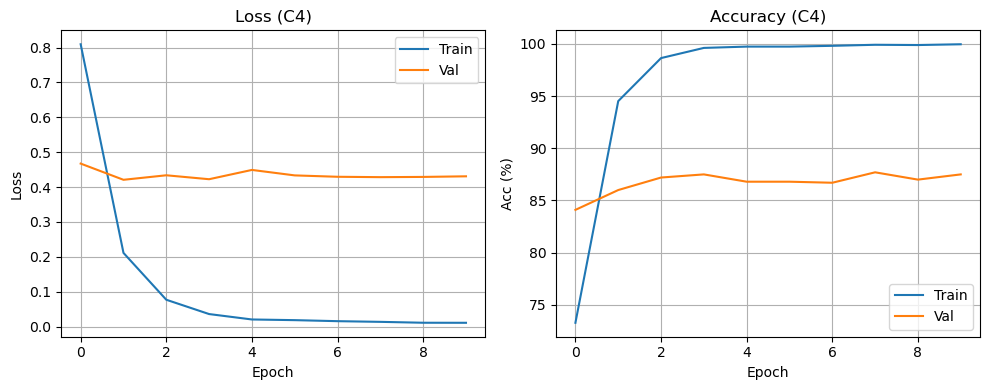

 Saved: classification_compare.png


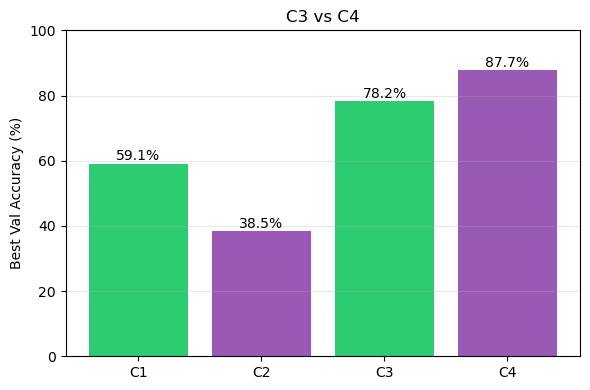

 Saved: runs.csv


In [51]:
from tqdm import tqdm
import json, pandas as pd, matplotlib.pyplot as plt

def evaluate(model, loader, criterion, device):
    model.eval()
    running_loss, correct, total = 0.0, 0, 0
    with torch.no_grad():
        for inputs, targets in loader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            running_loss += loss.item()
            _, predicted = outputs.max(1)
            total += targets.size(0)
            correct += predicted.eq(targets).sum().item()
    return running_loss/len(loader), 100.*correct/total

criterion = nn.CrossEntropyLoss()
test_loss, test_acc = evaluate(model_c4, test_loader, criterion, device)

print(f"\nTEST RESULTS (C4):", flush=True)
print(f"   Test Accuracy: {test_acc:.2f}%", flush=True)

for r in results:
    if r['experiment_id'] == 'C4':
        r['test_accuracy'] = test_acc

torch.save(model_c4.state_dict(), artifacts_dir / "best_classifier.pt")
print(f" Saved: best_classifier.pt", flush=True)

config = {
    "experiment_id": "C4",
    "dataset": "STL10",
    "architecture": "ResNet18-FineTune",
    "lr": 0.0001,
    "batch_size": 32,
    "epochs": 10,
    "optimizer": "Adam",
    "seed": SEED,
    "transforms": {
        "train": ["Resize(96)", "CenterCrop(96)", "ToTensor", "Normalize(ImageNet)"],
        "val": ["Resize(96)", "CenterCrop(96)", "ToTensor", "Normalize(ImageNet)"]
    },
    "augmentation": {
        "enabled": False,
        "transforms": ["RandomResizedCrop", "RandomHorizontalFlip", "ColorJitter"]
    }
}
with open(artifacts_dir / "best_classifier_config.json", "w") as f:
    json.dump(config, f, indent=2)
print(f" Saved: best_classifier_config.json", flush=True)

plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.plot(history_c4['train_loss'], label='Train')
plt.plot(history_c4['val_loss'], label='Val')
plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.title('Loss (C4)'); plt.legend(); plt.grid(True)
plt.subplot(1, 2, 2)
plt.plot(history_c4['train_acc'], label='Train')
plt.plot(history_c4['val_acc'], label='Val')
plt.xlabel('Epoch'); plt.ylabel('Acc (%)'); plt.title('Accuracy (C4)'); plt.legend(); plt.grid(True)
plt.tight_layout()
plt.savefig(figures_dir / "classification_curves_best.png", dpi=150, bbox_inches='tight')
print(f" Saved: classification_curves_best.png", flush=True)
plt.show()

exp_ids = [r['experiment_id'] for r in results]
val_accs = [r['best_val_accuracy'] for r in results]
plt.figure(figsize=(6, 4))
plt.bar(exp_ids, val_accs, color=['#2ecc71', '#9b59b6'])
plt.ylabel('Best Val Accuracy (%)'); plt.title('C3 vs C4'); plt.ylim(0, 100)
for i, (eid, acc) in enumerate(zip(exp_ids, val_accs)):
    plt.text(i, acc + 1, f'{acc:.1f}%', ha='center')
plt.grid(axis='y', alpha=0.3); plt.tight_layout()
plt.savefig(figures_dir / "classification_compare.png", dpi=150, bbox_inches='tight')
print(f" Saved: classification_compare.png", flush=True)
plt.show()

pd.DataFrame(results).to_csv(artifacts_dir / "runs.csv", index=False)
print(f" Saved: runs.csv", flush=True)

In [52]:
from torchvision.datasets import OxfordIIITPet
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights
import torch.nn.functional as F

print(" Loading OxfordIIITPet dataset...", flush=True)

segmentation_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

train_seg = OxfordIIITPet(root="./data_pets", split="trainval", download=True, transform=segmentation_transform)
test_seg = OxfordIIITPet(root="./data_pets", split="test", download=True, transform=segmentation_transform)

print(f"✓ Train/Val: {len(train_seg)} images", flush=True)
print(f"✓ Test: {len(test_seg)} images", flush=True)

from torch.utils.data import random_split
train_size = int(len(train_seg) * 0.8)
val_size = len(train_seg) - train_size
train_seg, val_seg = random_split(train_seg, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

print(f"✓ Train split: {len(train_seg)}", flush=True)
print(f"✓ Val split: {len(val_seg)}", flush=True)

batch_size_seg = 8
train_seg_loader = DataLoader(train_seg, batch_size=batch_size_seg, shuffle=True, num_workers=2)
val_seg_loader = DataLoader(val_seg, batch_size=batch_size_seg, shuffle=False, num_workers=2)
test_seg_loader = DataLoader(test_seg, batch_size=batch_size_seg, shuffle=False, num_workers=2)

print(f"\n OxfordIIITPet loaded!", flush=True)
print(f"   Classes: 3 (foreground pet, background, boundary)", flush=True)

 Loading OxfordIIITPet dataset...
✓ Train/Val: 3680 images
✓ Test: 3669 images
✓ Train split: 2944
✓ Val split: 736

 OxfordIIITPet loaded!
   Classes: 3 (foreground pet, background, boundary)


In [53]:
from torchvision.datasets import OxfordIIITPet

print(" Reloading OxfordIIITPet for segmentation...", flush=True)

img_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

mask_transform = transforms.Compose([
    transforms.Resize((224, 224), interpolation=transforms.InterpolationMode.NEAREST),
])

train_seg = OxfordIIITPet(
    root="./data_pets", 
    split="trainval", 
    download=True, 
    transform=img_transform,
    target_types=['segmentation'],
    target_transform=mask_transform
)

test_seg = OxfordIIITPet(
    root="./data_pets", 
    split="test", 
    download=True, 
    transform=img_transform,
    target_types=['segmentation'],
    target_transform=mask_transform
)

print(f" Train/Val: {len(train_seg)} images", flush=True)
print(f" Test: {len(test_seg)} images", flush=True)

img, mask = train_seg[0]
print(f"\n Image shape: {img.shape}", flush=True)
print(f" Mask type: {type(mask)}", flush=True)
if hasattr(mask, 'shape'):
    print(f" Mask shape: {mask.shape}", flush=True)

from torch.utils.data import random_split
train_size = int(len(train_seg) * 0.8)
val_size = len(train_seg) - train_size
train_seg_split, val_seg_split = random_split(train_seg, [train_size, val_size], generator=torch.Generator().manual_seed(SEED))

print(f" Train split: {len(train_seg_split)}", flush=True)
print(f" Val split: {len(val_seg_split)}", flush=True)

batch_size_seg = 8
train_seg_loader = DataLoader(train_seg_split, batch_size=batch_size_seg, shuffle=True, num_workers=2)
val_seg_loader = DataLoader(val_seg_split, batch_size=batch_size_seg, shuffle=False, num_workers=2)
test_seg_loader = DataLoader(test_seg, batch_size=batch_size_seg, shuffle=False, num_workers=2)

print(f"\n OxfordIIITPet loaded for segmentation!", flush=True)

 Reloading OxfordIIITPet for segmentation...
 Train/Val: 3680 images
 Test: 3669 images

 Image shape: torch.Size([3, 224, 224])
 Mask type: <class 'PIL.Image.Image'>
 Train split: 2944
 Val split: 736

 OxfordIIITPet loaded for segmentation!


 Saved: segmentation_examples.png


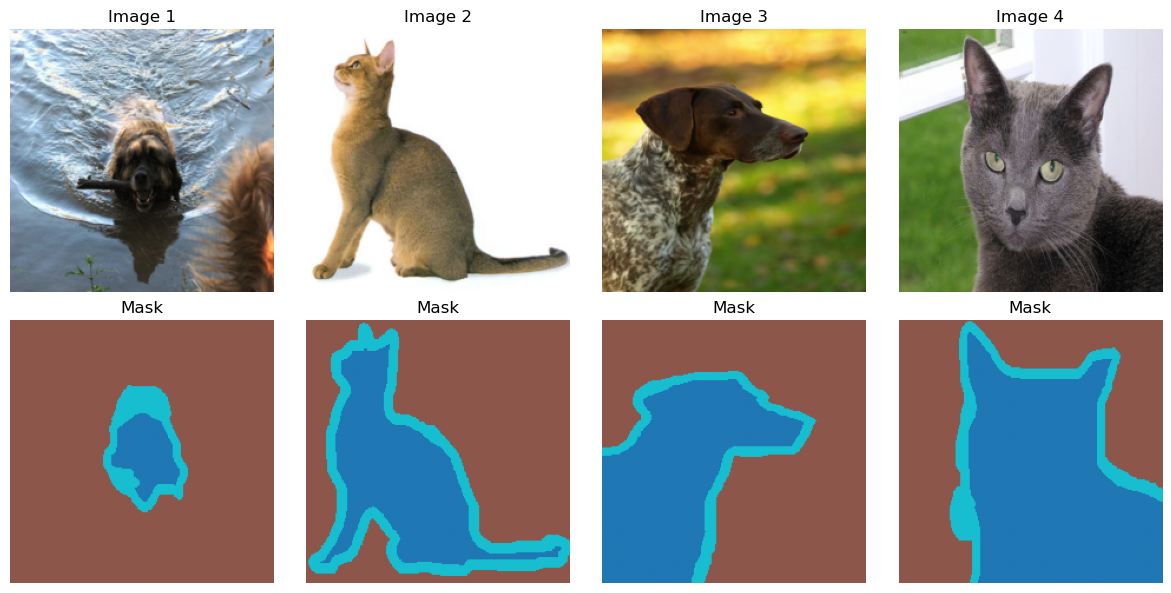

In [54]:
def visualize_segmentation_sample(dataset, num_samples=4):
    fig, axes = plt.subplots(2, num_samples, figsize=(12, 6))
    
    for i in range(num_samples):
        img, mask = dataset[i]
        
        img_denorm = img * torch.tensor(IMAGENET_STD).view(3, 1, 1) + torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        img_denorm = img_denorm.permute(1, 2, 0).clamp(0, 1)
        
        mask_array = np.array(mask)
        
        axes[0, i].imshow(img_denorm)
        axes[0, i].set_title(f"Image {i+1}")
        axes[0, i].axis('off')
        
        im = axes[1, i].imshow(mask_array, cmap='tab10')
        axes[1, i].set_title(f"Mask")
        axes[1, i].axis('off')
    
    plt.tight_layout()
    plt.savefig(figures_dir / "segmentation_examples.png", dpi=150, bbox_inches='tight')
    print(f" Saved: segmentation_examples.png", flush=True)
    plt.show()

visualize_segmentation_sample(train_seg_split, num_samples=4)

In [55]:
from torchvision.models.segmentation import deeplabv3_resnet50, DeepLabV3_ResNet50_Weights

print(" Loading DeepLabV3 model...", flush=True)

model_seg = deeplabv3_resnet50(weights=DeepLabV3_ResNet50_Weights.COCO_WITH_VOC_LABELS_V1)
model_seg = model_seg.to(device)
model_seg.eval()

print(f" Model loaded: {sum(p.numel() for p in model_seg.parameters()):,} parameters", flush=True)
print(f" Device: {device}", flush=True)
print(f"\n Model ready!", flush=True)

 Loading DeepLabV3 model...
 Model loaded: 42,004,074 parameters
 Device: cuda

 Model ready!


In [56]:
def predict_mask(model, image_tensor, device, threshold=0.5):
    model.eval()
    with torch.no_grad():
        input_tensor = image_tensor.unsqueeze(0).to(device)
        output = model(input_tensor)['out']
        foreground_prob = torch.softmax(output, dim=1)[0, 1:].max(dim=0)[0]
        mask = (foreground_prob > threshold).float()
    
    return mask.cpu(), foreground_prob.cpu()

def calculate_iou(pred_mask, true_mask, threshold=0.5):
    true_binary = (np.array(true_mask) == 1).astype(float)
    
    pred_binary = pred_mask.numpy() if hasattr(pred_mask, 'numpy') else pred_mask
    intersection = np.sum(pred_binary * true_binary)
    union = np.sum(np.clip(pred_binary + true_binary, 0, 1))
    
    if union == 0:
        return 1.0 if intersection == 0 else 0.0
    
    return intersection / union

def calculate_pixel_metrics(pred_mask, true_mask):
    true_binary = (np.array(true_mask) == 1).astype(float)
    pred_binary = pred_mask.numpy() if hasattr(pred_mask, 'numpy') else pred_mask
    
    tp = np.sum((pred_binary == 1) & (true_binary == 1))
    fp = np.sum((pred_binary == 1) & (true_binary == 0))
    fn = np.sum((pred_binary == 0) & (true_binary == 1))
    
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    
    return precision, recall

print(" Functions defined", flush=True)

 Functions defined


In [57]:
print("\n Running V1: Basic post-processing (threshold=0.5)", flush=True)

iou_scores_v1 = []
precision_v1 = []
recall_v1 = []

num_eval = 20
for i in range(num_eval):
    img, true_mask = test_seg[i]
    pred_mask, _ = predict_mask(model_seg, img, device, threshold=0.5)
    
    iou = calculate_iou(pred_mask, true_mask)
    prec, rec = calculate_pixel_metrics(pred_mask, true_mask)
    
    iou_scores_v1.append(iou)
    precision_v1.append(prec)
    recall_v1.append(rec)

mean_iou_v1 = np.mean(iou_scores_v1)
mean_prec_v1 = np.mean(precision_v1)
mean_rec_v1 = np.mean(recall_v1)

print(f"\n V1 Results (n={num_eval}):", flush=True)
print(f"   Mean IoU: {mean_iou_v1:.4f}", flush=True)
print(f"   Pixel Precision: {mean_prec_v1:.4f}", flush=True)
print(f"   Pixel Recall: {mean_rec_v1:.4f}", flush=True)

results.append({
    'experiment_id': 'V1',
    'task': 'segmentation',
    'dataset': 'OxfordIIITPet',
    'seed': SEED,
    'model_summary': 'DeepLabV3-ResNet50',
    'optimizer': 'N/A (pretrained)',
    'lr': 'N/A',
    'epochs_trained': 0,
    'best_val_accuracy': None,
    'test_accuracy': None,
    'precision': mean_prec_v1,
    'recall': mean_rec_v1,
    'mean_iou': mean_iou_v1,
    'notes': 'Basic post-processing, threshold=0.5'
})


 Running V1: Basic post-processing (threshold=0.5)

 V1 Results (n=20):
   Mean IoU: 0.6862
   Pixel Precision: 0.6934
   Pixel Recall: 0.9830


In [58]:
print("\n Running V2: Alternative post-processing (threshold=0.7 + morphological cleanup)", flush=True)

from scipy import ndimage

def postprocess_mask(pred_mask, threshold=0.7, min_area=100):
    binary = (pred_mask > threshold).astype(float)
    labeled, num = ndimage.label(binary.astype(int))
    for i in range(1, num + 1):
        if np.sum(labeled == i) < min_area:
            binary[labeled == i] = 0
    
    return binary

iou_scores_v2 = []
precision_v2 = []
recall_v2 = []

for i in range(num_eval):
    img, true_mask = test_seg[i]
    
    _, prob_map = predict_mask(model_seg, img, device, threshold=0)  # берём prob_map
    pred_mask_raw = prob_map.numpy() if hasattr(prob_map, 'numpy') else prob_map
    
    pred_mask = postprocess_mask(pred_mask_raw, threshold=0.7, min_area=100)
    
    iou = calculate_iou(pred_mask, true_mask)
    prec, rec = calculate_pixel_metrics(pred_mask, true_mask)
    
    iou_scores_v2.append(iou)
    precision_v2.append(prec)
    recall_v2.append(rec)

mean_iou_v2 = np.mean(iou_scores_v2)
mean_prec_v2 = np.mean(precision_v2)
mean_rec_v2 = np.mean(recall_v2)

print(f"\n V2 Results (n={num_eval}):", flush=True)
print(f"   Mean IoU: {mean_iou_v2:.4f}", flush=True)
print(f"   Pixel Precision: {mean_prec_v2:.4f}", flush=True)
print(f"   Pixel Recall: {mean_rec_v2:.4f}", flush=True)

results.append({
    'experiment_id': 'V2',
    'task': 'segmentation',
    'dataset': 'OxfordIIITPet',
    'seed': SEED,
    'model_summary': 'DeepLabV3-ResNet50',
    'optimizer': 'N/A (pretrained)',
    'lr': 'N/A',
    'epochs_trained': 0,
    'best_val_accuracy': None,
    'test_accuracy': None,
    'precision': mean_prec_v2,
    'recall': mean_rec_v2,
    'mean_iou': mean_iou_v2,
    'notes': 'Threshold=0.7 + remove small components (min_area=100)'
})


 Running V2: Alternative post-processing (threshold=0.7 + morphological cleanup)

 V2 Results (n=20):
   Mean IoU: 0.7317
   Pixel Precision: 0.7736
   Pixel Recall: 0.9123


In [59]:
print(" Saving segmentation artifacts...", flush=True)

def visualize_predictions(model, dataset, num_samples=4, threshold=0.5, title=""):
    fig, axes = plt.subplots(3, num_samples, figsize=(15, 9))
    
    for i in range(num_samples):
        img, true_mask = dataset[i]
        pred_mask, _ = predict_mask(model, img, device, threshold=threshold)
        
        img_denorm = img * torch.tensor(IMAGENET_STD).view(3, 1, 1) + torch.tensor(IMAGENET_MEAN).view(3, 1, 1)
        img_denorm = img_denorm.permute(1, 2, 0).clamp(0, 1)
        
        true_array = np.array(true_mask) == 1
        pred_array = pred_mask.numpy() if hasattr(pred_mask, 'numpy') else pred_mask
        
        axes[0, i].imshow(img_denorm)
        axes[0, i].set_title(f"Image {i+1}")
        axes[0, i].axis('off')
        
        axes[1, i].imshow(true_array, cmap='gray')
        axes[1, i].set_title("Ground Truth")
        axes[1, i].axis('off')
        
        axes[2, i].imshow(pred_array, cmap='gray')
        axes[2, i].set_title(f"Prediction (t={threshold})")
        axes[2, i].axis('off')
    
    plt.suptitle(title, fontsize=14, y=0.98)
    plt.tight_layout()
    return fig

fig_v1 = visualize_predictions(model_seg, test_seg, num_samples=4, threshold=0.5, title="V1: threshold=0.5")
plt.savefig(figures_dir / "segmentation_examples.png", dpi=150, bbox_inches='tight')
print(f" Saved: segmentation_examples.png (V1 predictions)", flush=True)
plt.close()

metrics_data = {
    'Experiment': ['V1', 'V2'],
    'Mean IoU': [mean_iou_v1, mean_iou_v2],
    'Precision': [mean_prec_v1, mean_prec_v2],
    'Recall': [mean_rec_v1, mean_rec_v2]
}
metrics_df = pd.DataFrame(metrics_data)

fig, ax = plt.subplots(figsize=(8, 5))
x = np.arange(len(metrics_data['Experiment']))
width = 0.25

ax.bar(x - width, metrics_data['Mean IoU'], width, label='Mean IoU', alpha=0.8)
ax.bar(x, metrics_data['Precision'], width, label='Precision', alpha=0.8)
ax.bar(x + width, metrics_data['Recall'], width, label='Recall', alpha=0.8)

ax.set_ylabel('Score')
ax.set_title('Segmentation Metrics: V1 vs V2')
ax.set_xticks(x)
ax.set_xticklabels(metrics_data['Experiment'])
ax.legend()
ax.grid(axis='y', alpha=0.3)
ax.set_ylim(0, 1.1)

plt.tight_layout()
plt.savefig(figures_dir / "segmentation_metrics.png", dpi=150, bbox_inches='tight')
print(f" Saved: segmentation_metrics.png", flush=True)
plt.close()

pd.DataFrame(results).to_csv(artifacts_dir / "runs.csv", index=False)
print(f" Updated: runs.csv", flush=True)

print(f"\n ALL ARTIFACTS SAVED FOR PART B!", flush=True)

 Saving segmentation artifacts...
 Saved: segmentation_examples.png (V1 predictions)
 Saved: segmentation_metrics.png
 Updated: runs.csv

 ALL ARTIFACTS SAVED FOR PART B!
